In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [4]:
ZIP_PATH = "/content/drive/MyDrive/new plant diseases/New Plant Diseases Datasets.zip"
UNZIP_DIR = "/content/dataset"


In [5]:
import zipfile
import os

# create folder if not exists
os.makedirs(UNZIP_DIR, exist_ok=True)

# unzip only if not already unzipped
if not os.listdir(UNZIP_DIR):
    print("Unzipping dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(UNZIP_DIR)
    print("Unzip completed ")
else:
    print("Dataset already unzipped ")

Unzipping dataset...
Unzip completed 


In [6]:
for root, dirs, files in os.walk(UNZIP_DIR):
    print(root)
    break


/content/dataset


In [7]:
BASE_PATH = "/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

train_path = os.path.join(BASE_PATH, "train")
valid_path = os.path.join(BASE_PATH, "valid")


In [8]:
print("Train folders:", len(os.listdir(train_path)))
print("Valid folders:", len(os.listdir(valid_path)))


Train folders: 38
Valid folders: 38


In [9]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import warnings
import os
import time

from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import Xception, xception
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore')

In [10]:
NUM_CLASSES = 38
IMG_SIZE = (299, 299)
BATCH_SIZE = 32

INITIAL_EPOCHS = 5
FINE_TUNE_EPOCHS = 5
TOTAL_EPOCHS = INITIAL_EPOCHS + FINE_TUNE_EPOCHS

MODEL_ID = "Xception"
TRAIN_PORTION = 0.5

In [11]:
print("\nLoading Training Set...")

training_set = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=True
)

total_batches = training_set.cardinality().numpy()

training_set = training_set.shuffle(100).take(int(total_batches * TRAIN_PORTION))

print(f"Training set loaded, using {int(total_batches * TRAIN_PORTION)} batches ({TRAIN_PORTION*100}%).")

validation_set = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=True
)

test_set = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=1,
    color_mode="rgb",
    shuffle=False
)

class_name = test_set.class_names



Loading Training Set...
Found 70295 files belonging to 38 classes.
Training set loaded, using 1098 batches (50.0%).
Found 17572 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.


In [12]:
base_xception = Xception(
    weights="imagenet",
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)

base_xception.trainable = False

xception_model = tf.keras.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    layers.Lambda(xception.preprocess_input),
    base_xception,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
xception_model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

xception_model.summary()

print(f"\nStarting Phase 1 for {INITIAL_EPOCHS} epochs...")
start_time = time.time()

history_initial = xception_model.fit(
    training_set,
    validation_data=validation_set,
    epochs=INITIAL_EPOCHS
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 10, 10, 2048)   │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,395,790 (81.62 MB)

 Trainable params: 534,310 (2.04 MB)

 Non-trainable params: 20,861,480 (79.58 MB)


Starting Phase 1 for 5 epochs...
Epoch 1/5
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 494s 408ms/step - accuracy: 0.7314 - loss: 1.0256 - val_accuracy: 0.9139 - val_loss: 0.2706
Epoch 2/5
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 378s 339ms/step - accuracy: 0.9119 - loss: 0.2690 - val_accuracy: 0.9264 - val_loss: 0.2251
Epoch 3/5
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 377s 339ms/step - accuracy: 0.9291 - loss: 0.2100 - val_accuracy: 0.9369 - val_loss: 0.1866
Epoch 4/5
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 376s 339ms/step - accuracy: 0.9386 - loss: 0.1805 - val_accuracy: 0.9399 - val_loss: 0.1766
Epoch 5/5
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 376s 339ms/step - accuracy: 0.9458 - loss: 0.1570 - val_accuracy: 0.9356 - val_loss: 0.1872


In [14]:
early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)




In [15]:
base_xception.trainable = True

UNFREEZE_LAYERS_FROM = len(base_xception.layers) - 40
for layer in base_xception.layers[:UNFREEZE_LAYERS_FROM]:
    layer.trainable = False

xception_model.compile(
    optimizer=optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine_tune = xception_model.fit(
    training_set,
    validation_data=validation_set,
    epochs=TOTAL_EPOCHS,
    initial_epoch=history_initial.epoch[-1] + 1,
    callbacks=[early_stopping, lr_scheduler]
)

Epoch 6/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 584s 499ms/step - accuracy: 0.8503 - loss: 0.5356 - val_accuracy: 0.9136 - val_loss: 0.3169 - learning_rate: 1.0000e-05
Epoch 7/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 528s 478ms/step - accuracy: 0.9584 - loss: 0.1274 - val_accuracy: 0.9474 - val_loss: 0.1860 - learning_rate: 1.0000e-05
Epoch 8/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 547s 495ms/step - accuracy: 0.9743 - loss: 0.0748 - val_accuracy: 0.9467 - val_loss: 0.1930 - learning_rate: 1.0000e-05
Epoch 9/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 547s 495ms/step - accuracy: 0.9827 - loss: 0.0521 - val_accuracy: 0.9637 - val_loss: 0.1273 - learning_rate: 1.0000e-05
Epoch 10/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 547s 495ms/step - accuracy: 0.9870 - loss: 0.0378 - val_accuracy: 0.9691 - val_loss: 0.1054 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 10.


In [16]:
end_time = time.time()
print(f"Training Time: {(end_time-start_time):.2f} seconds")

train_loss, train_acc = xception_model.evaluate(training_set, verbose=0)
val_loss, val_acc = xception_model.evaluate(validation_set, verbose=0)

print(f"Train Acc: {train_acc:.4f}")
print(f"Val Acc: {val_acc:.4f}")



Training Time: 4753.22 seconds
Train Acc: 0.9937
Val Acc: 0.9691


In [20]:
y_pred_probs = xception_model.predict(test_set, verbose=0)
Y_true = tf.concat([y for x, y in test_set], axis=0).numpy()
Y_pred = tf.argmax(y_pred_probs, axis=1).numpy()

report = classification_report(Y_true, Y_pred, target_names=class_name,output_dict=True)

print(classification_report(Y_true, Y_pred, target_names=class_name, digits=4))


                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9959    0.9563    0.9757       504
                                 Apple___Black_rot     0.9861    1.0000    0.9930       497
                          Apple___Cedar_apple_rust     0.9796    0.9841    0.9819       440
                                   Apple___healthy     0.9979    0.9562    0.9766       502
                               Blueberry___healthy     0.9680    1.0000    0.9837       454
          Cherry_(including_sour)___Powdery_mildew     0.9953    1.0000    0.9976       421
                 Cherry_(including_sour)___healthy     0.9934    0.9934    0.9934       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9212    0.9415    0.9312       410
                       Corn_(maize)___Common_rust_     1.0000    0.9937    0.9968       477
               Corn_(maize)___Northern_Leaf_Blight     0.9436    0.9476    0.94

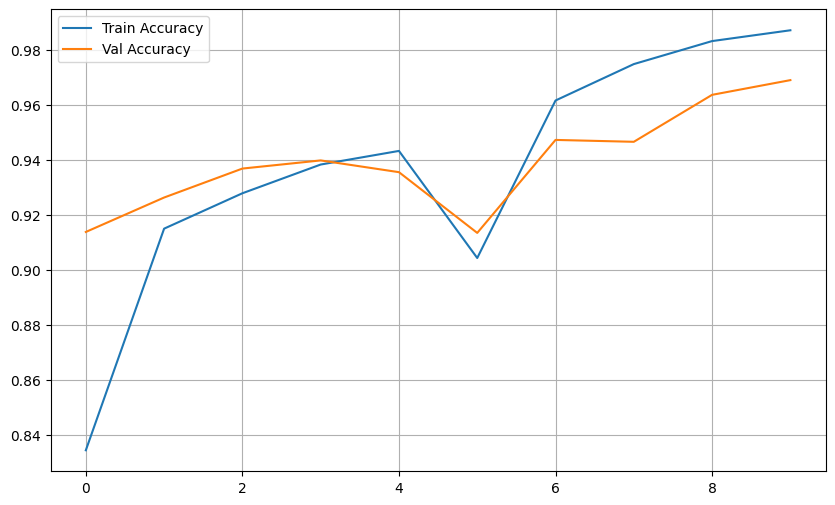

In [18]:
history = {
    'accuracy': history_initial.history['accuracy'] + history_fine_tune.history['accuracy'],
    'val_accuracy': history_initial.history['val_accuracy'] + history_fine_tune.history['val_accuracy'],
}

plt.figure(figsize=(10,6))
plt.plot(history['accuracy'], label="Train Accuracy")
plt.plot(history['val_accuracy'], label="Val Accuracy")
plt.legend()
plt.grid()
plt.show()


In [22]:
results_file = "/content/drive/MyDrive/new plant diseases/model_performance_summary.csv"

metrics_summary = {
    'Model': MODEL_ID,
    'Accuracy': report['accuracy'],
    'Precision': report['weighted avg']['precision'],
    'Recall': report['weighted avg']['recall'],
    'F1-Score': report['weighted avg']['f1-score']
}

pd.DataFrame([metrics_summary]).to_csv(results_file, index=False)
print("Metrics saved to Drive")


Metrics saved to Drive
